# EDA - Data Análisis de HateScan

### Proyecto Grupal — Data Análisis de HateScan

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Sección | Qué vamos a hacer |
|--------|-------------------|
| **1** | Importar librerías y cargar datos |
| **2** | Inspección del dataset |
| **3** | Tipos de datos |
| **4** | Calidad de los datos |
| **5** | Distribución del target principal IsToxic |
| **6** | Distribución de las 12 etiquetas |
| **7** | Identificación de etiquetas no modelables |
| **8** | Longitud de comentarios |
| **9** | Distribución de longitud |
| **10** | Longitud vs toxicidad |
| **11** | WordClouds por categoría tóxica |
| **12** | Correlación entre etiquetas |
| **13** | Análisis de multi-label |
| **14** | Conclusiones accionables para el pipeline NLP |
| **15** | Resumen ejecutivo |

---

# Sección 1

## Importando librerías

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## Leyendo youtoxic_english_1000.csv en formato csv

In [2]:
df = pd.read_csv('../data/raw/youtoxic_english_1000.csv')

# Obtener filas y columnas
filas, columnas = df.shape
print(f'✅ Dataset youtoxic_english_1000.csv cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset youtoxic_english_1000.csv cargado correctamente
📊 Dimensiones: 1000 filas x 15 columnas


# Sección 2

## Inspección del dataset

**¿Cuántas filas y columnas tiene?**

In [3]:
# Obtener filas y columnas
filas, columnas = df.shape
print(f'📊 Dimensiones del Dataset df_all : {filas} filas x {columnas} columnas')

📊 Dimensiones del Dataset df_all : 1000 filas x 15 columnas


### Test de dimensiones del DataSet esperado

In [4]:
# Número de Columnas y Filas esperado
assert df.shape == (1000, 15)

# sección 3

## Tipos de datos

In [5]:
# Ver 10 filas al azar
df.sample(9)

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
925,UghjJWezfp-IzngCoAEC,TZxEyoplYbI,"Fergueson residents are stupid , they complain...",True,False,False,False,False,True,True,False,False,False,False,False
253,UgzpYKnjIcmB7Ch15YR4AaABAg,8HB18hZrhXc,"I'm with cops. Those protesters steal, and des...",True,True,False,False,True,False,False,False,False,False,False,False
656,UgxXe27x-ZA6YeZFf5R4AaABAg,cT14IbTDW2c,"German Police is pretty ""nice"" but even they w...",False,False,False,False,False,False,False,False,False,False,False,False
75,UghY8Jytv5XqC3gCoAEC,04kJtp6pVXI,Lmfao why is this dude taking like that??? -_\...,False,False,False,False,False,False,False,False,False,False,False,False
786,UgiDRFxEd3lXsHgCoAEC,dG7mZQvaQDk,She spoke what on others want to say....,False,False,False,False,False,False,False,False,False,False,False,False
250,Ugyg_kgb1QWkAWdEKsd4AaABAg,8HB18hZrhXc,Kill all protesters,True,True,True,False,False,False,False,False,False,False,False,False
602,UgjwfZG_znrrvXgCoAEC,cT14IbTDW2c,Blacks are able to do this because it was Whit...,True,False,False,False,False,True,True,False,False,False,False,False
603,UgjY_1PbjqkGAXgCoAEC,cT14IbTDW2c,cop dont even do anything wtf.protesters i wan...,True,True,True,False,False,False,False,False,False,False,False,False
869,UgzznaHifWKSzSekoZ94AaABAg,Dt9-byUhPdg,National Guard should be called out at the hin...,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
# Información general del dataset
print('ℹ️ Información del dataset:')
df.info()

ℹ️ Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CommentId        1000 non-null   str  
 1   VideoId          1000 non-null   str  
 2   Text             1000 non-null   str  
 3   IsToxic          1000 non-null   bool 
 4   IsAbusive        1000 non-null   bool 
 5   IsThreat         1000 non-null   bool 
 6   IsProvocative    1000 non-null   bool 
 7   IsObscene        1000 non-null   bool 
 8   IsHatespeech     1000 non-null   bool 
 9   IsRacist         1000 non-null   bool 
 10  IsNationalist    1000 non-null   bool 
 11  IsSexist         1000 non-null   bool 
 12  IsHomophobic     1000 non-null   bool 
 13  IsReligiousHate  1000 non-null   bool 
 14  IsRadicalism     1000 non-null   bool 
dtypes: bool(12), str(3)
memory usage: 248.8 KB


**Ninguna de las columnas tiene valores nulos.**

**Las columnas CommentId y VideoId son ids y no aportan nada; se podrían borrar.**

# Sección 4

## Calidad de los datos

### 4.1 Test de Dataset sin nulos

In [7]:
# Dataset sin nulos
assert df.isnull().sum().sum() == 0

### 4.2 Estadísticas de los datos

In [8]:
# Estadísticas descriptivas de las columnas numéricas (describe)
# count=cuántos valores hay | mean=promedio | std=dispersión | min/max=extremos
df.describe()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,13,997,2,2,2,2,2,2,2,2,2,1,2,1
top,Ugg2KwwX0V8-aXgCoAEC,9pr1oE34bIM,run them over,False,False,False,False,False,False,False,False,False,False,False,False
freq,1,274,3,538,647,979,839,900,862,875,992,999,1000,988,1000


**Hay 13 videos comentados (VideoId) y en los campos IsHomophobic e IsRadicalism todos los valores son False.**

**En la columna Text hay 997 valores únicos de 1000, por lo tanto habrá 3 comentarios repetidos ???**

### 4.3 Test de labels unicamente binarias

In [9]:
label_cols = [
    'IsToxic',
    'IsAbusive',
    'IsThreat',
    'IsProvocative',
    'IsObscene',
    'IsHatespeech',
    'IsRacist',
    'IsNationalist',
    'IsSexist',
    'IsHomophobic',
    'IsReligiousHate',
    'IsRadicalism'
]

for col in label_cols:
    unique_values = set(df[col].astype(int).unique())
    assert unique_values.issubset({0,1})

### 4.4 Test de balance de la columna IsToxic

In [10]:
toxic_ratio = df['IsToxic'].mean()

assert 0.40 <= toxic_ratio <= 0.60

# Sección 5

## Distribución del target principal IsToxic

In [11]:
toxic_counts = df['IsToxic'].value_counts()
print(toxic_counts)

IsToxic
False    538
True     462
Name: count, dtype: int64


### Visualización

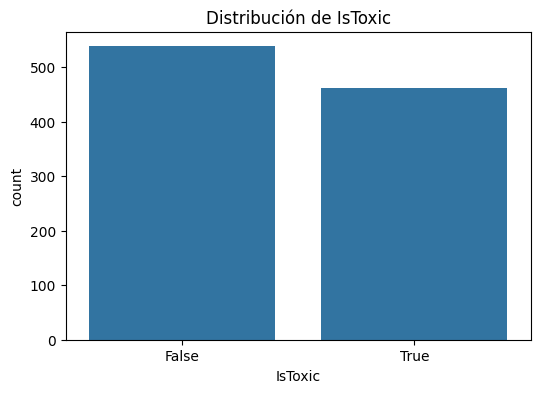

In [12]:
# Visualización
plt.figure(figsize=(6,4))
sns.countplot(x='IsToxic', data=df)
plt.title('Distribución de IsToxic')
plt.show()

---

#### Interpretación

El dataset está relativamente balanceado:

- 46.2% tóxicos

- 53.8% no tóxicos

Esto es MUY importante porque:

- evita problemas severos de class imbalance

accuracy podría ser una métrica válida inicialmente, aun así conviene usar:
- F1-score
- Precision
- Recall

especialmente porque el problema es clasificación tóxica.

---

# Sección 6

## Distribución de las 12 etiquetas

In [13]:
label_distribution = pd.DataFrame({
    'positives': df[label_cols].sum(),
    'negatives': len(df) - df[label_cols].sum()
})

label_distribution.sort_values('positives', ascending=False)

,positives,negatives
IsToxic,462,538
IsAbusive,353,647
IsProvocative,161,839
IsHatespeech,138,862
IsRacist,125,875
IsObscene,100,900
IsThreat,21,979
IsReligiousHate,12,988
IsNationalist,8,992
IsSexist,1,999


### Visualización

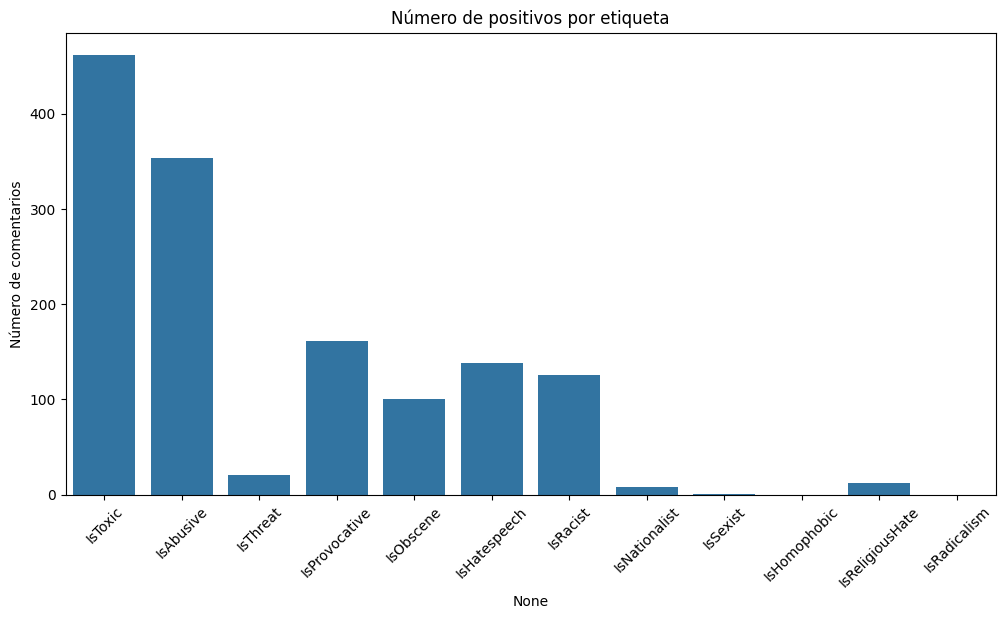

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=label_distribution.index,
    y=label_distribution['positives']
)

plt.xticks(rotation=45)
plt.title('Número de positivos por etiqueta')
plt.ylabel('Número de comentarios')
plt.show()

# Sección 7

## Identificación de etiquetas no modelables

In [15]:
label_distribution['positives']

IsToxic            462
IsAbusive          353
IsThreat            21
IsProvocative      161
IsObscene          100
IsHatespeech       138
IsRacist           125
IsNationalist        8
IsSexist             1
IsHomophobic         0
IsReligiousHate     12
IsRadicalism         0
Name: positives, dtype: int64

---

#### Resultado esperado

| Label | Positivos |
|--------|-------------------|
| IsNationalist | 8 |
| IsSexist | 1 |
| IsHomophobic | 0 |
| IsRadicalism | 0 |

#### Interpretación

Estas etiquetas NO son modelables.

#### ¿Por qué?

Un modelo supervisado necesita suficientes ejemplos positivos.

Problemas:

- IsSexist → solo 1 ejemplo.
- IsHomophobic → ningún positivo.
- IsRadicalism → ningún positivo.

Un modelo:

- no puede generalizar
- aprendería ruido
- produciría overfitting extremo

#### Decisión técnica

Estas columnas deben:

- excluirse del entrenamiento
- o tratarse únicamente como análisis descriptivo

---

# Sección 8

## Longitud de los comentarios

### Crear features de longitud

In [16]:
df['char_length'] = df['Text'].apply(len)
df['word_length'] = df['Text'].apply(lambda x: len(str(x).split()))

In [17]:
df.head(3)

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism,char_length,word_length
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False,1558,287
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False,138,25
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\r\nDont you reckon them 'black lives matter' ...,True,True,False,False,True,False,False,False,False,False,False,False,421,77


# Sección 9

## Distribución de longitud

### Longitud por caracteres

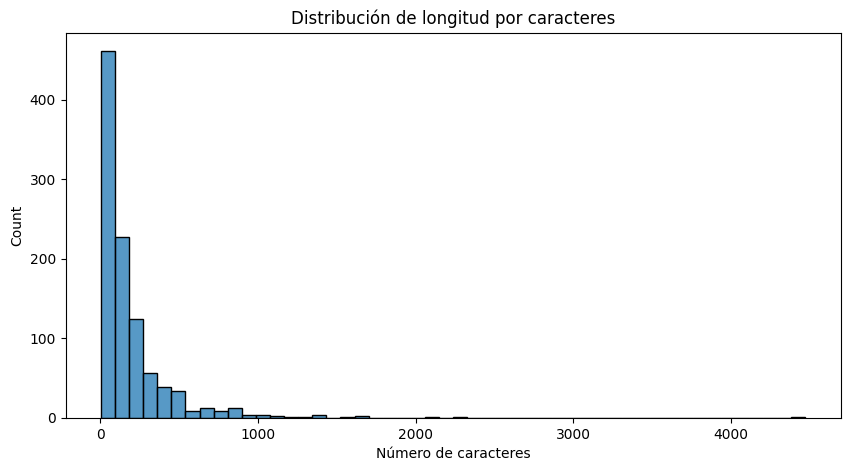

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df['char_length'], bins=50)

plt.title('Distribución de longitud por caracteres')
plt.xlabel('Número de caracteres')
plt.show()

### Longitud por palabras

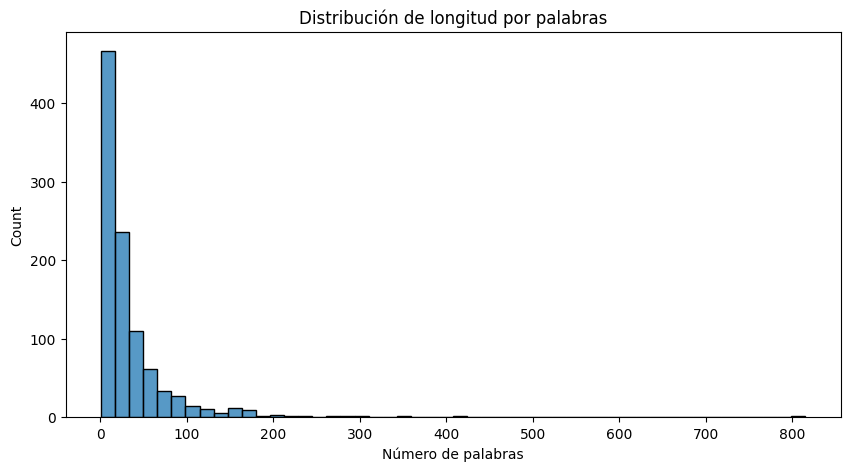

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df['word_length'], bins=50)

plt.title('Distribución de longitud por palabras')
plt.xlabel('Número de palabras')
plt.show()

# Sección 10

## Longitud vs toxicidad

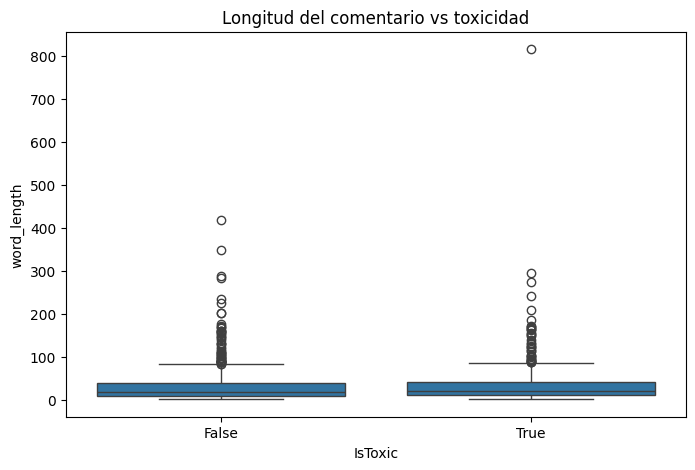

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='IsToxic',
    y='word_length',
    data=df
)

plt.title('Longitud del comentario vs toxicidad')
plt.show()

---

#### Interpretación

Este análisis sirve para detectar:

- si comentarios tóxicos son más cortos
- si insultos aparecen en mensajes breves
- si textos largos contienen más provocación contextual

Esto puede afectar:

- truncation
- max_length del tokenizer
- limpieza de stopwords

---

# Sección 11

## WordClouds por categoría tóxica

### Función auxiliar

In [21]:
def generate_wordcloud(text, title):
    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(15,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

### WordCloud de comentarios tóxicos

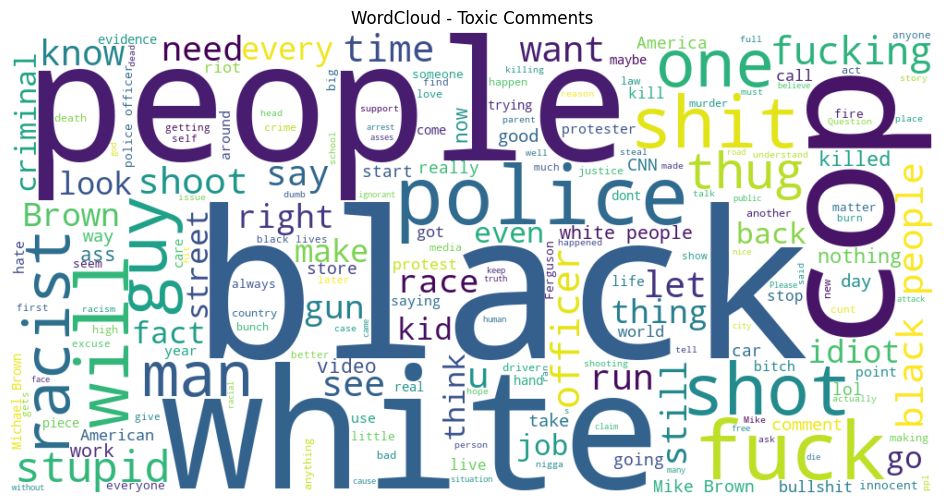

In [22]:
toxic_text = ' '.join(df[df['IsToxic']]['Text'])

generate_wordcloud(toxic_text, 'WordCloud - Toxic Comments')

### WordCloud por etiquetas

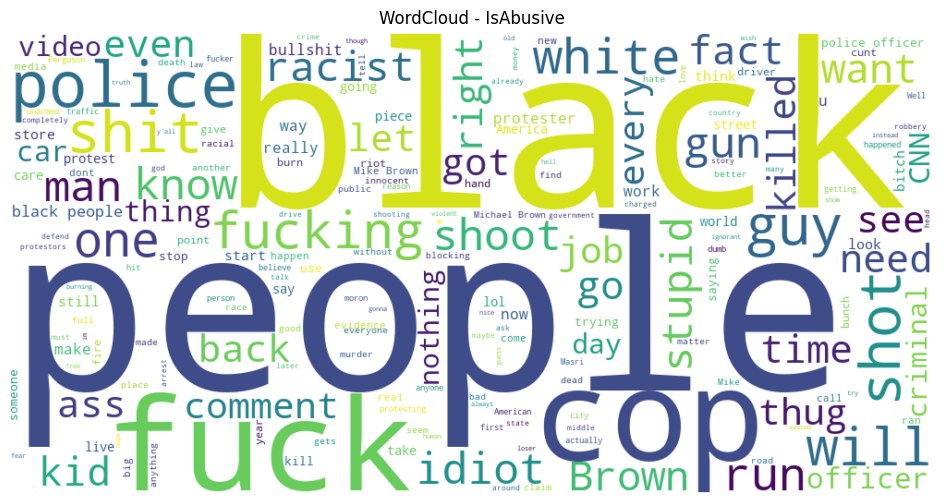

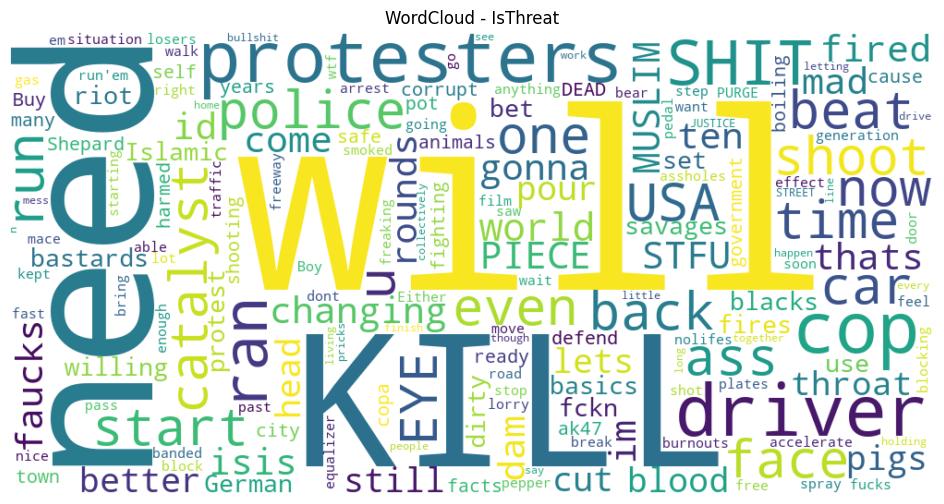

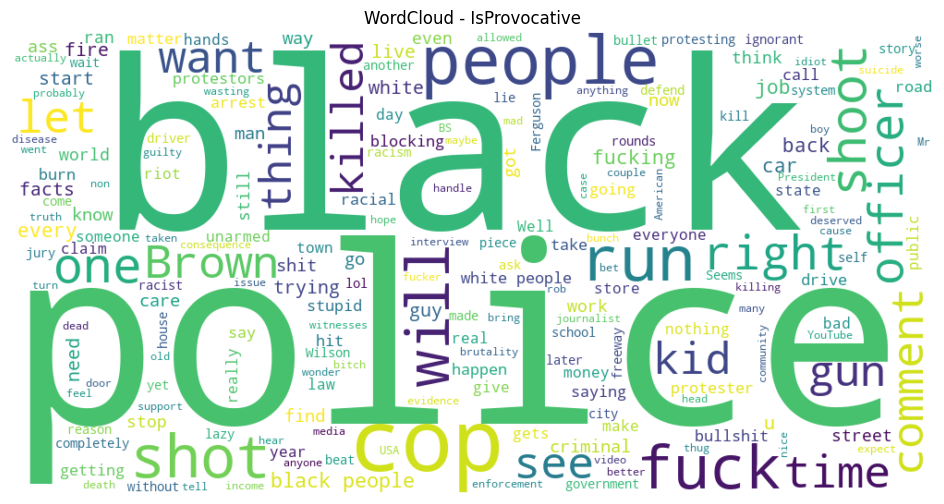

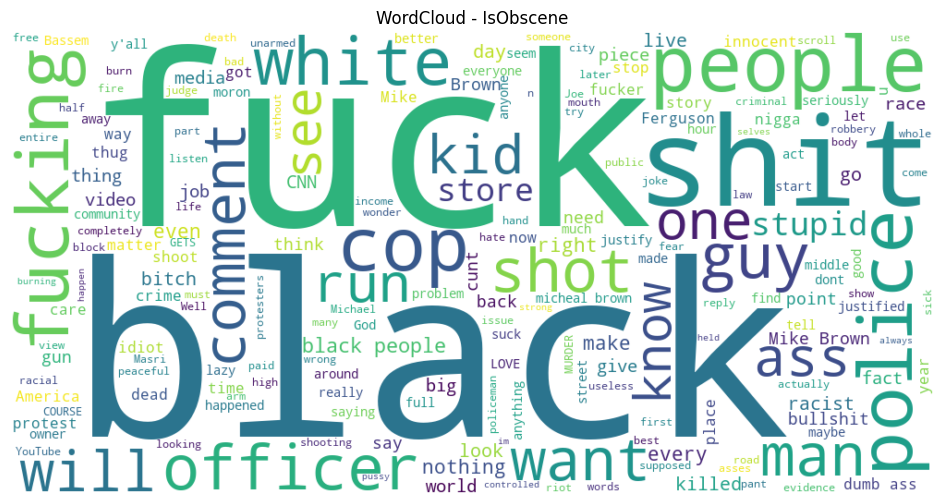

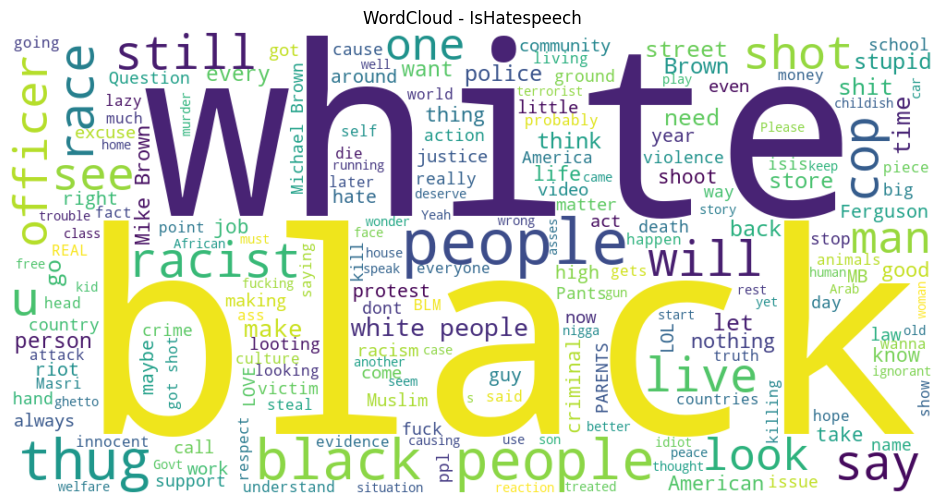

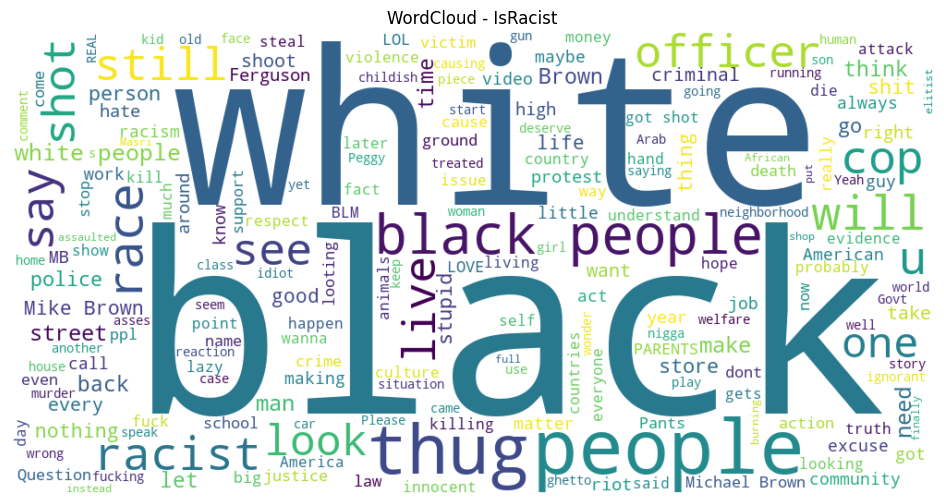

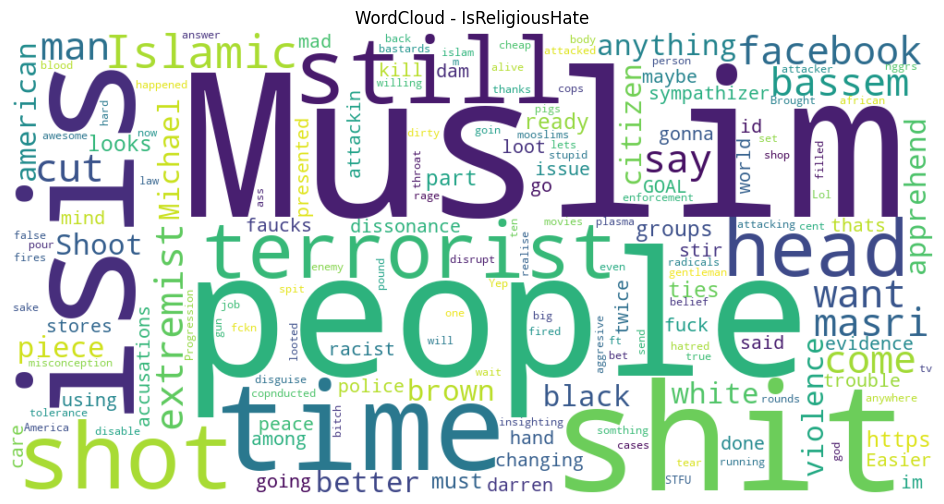

In [23]:
modelable_labels = [
    'IsAbusive',
    'IsThreat',
    'IsProvocative',
    'IsObscene',
    'IsHatespeech',
    'IsRacist',
    'IsReligiousHate'
]

for label in modelable_labels:

    text = ' '.join(df[df[label]]['Text'])

    if len(text.strip()) > 0:
        generate_wordcloud(text, f'WordCloud - {label}')

---

Qué buscamos aquí

- insultos recurrentes
- slurs
- patrones léxicos
- profanity
- hate speech

Esto ayuda muchísimo en:

- normalización
- diccionarios custom
- regex
- detección de emojis/tokens

---

# Sección 12

## 12.1 Correlación entre etiquetas

### Convertimos booleanos a enteros

In [24]:
corr_df = df[label_cols].astype(int)

### Matriz de correlación

In [25]:
corr_matrix = corr_df.corr()

### Heatmap

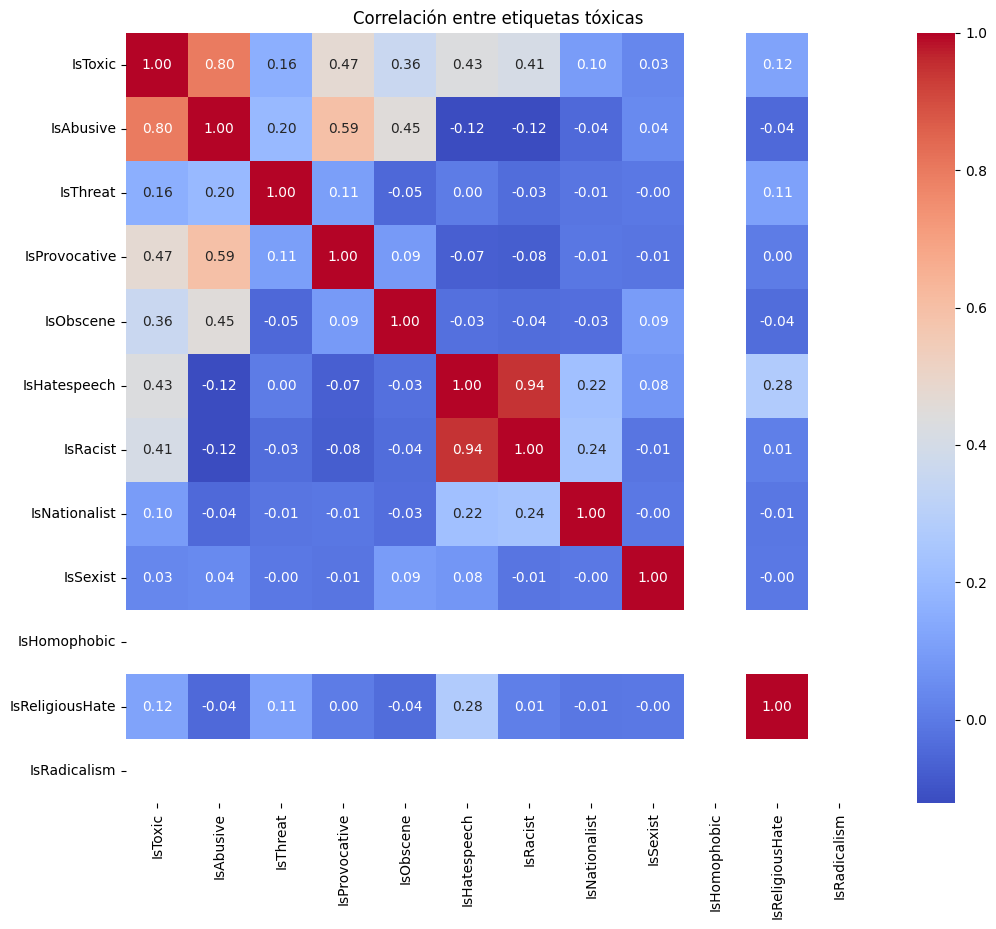

In [26]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlación entre etiquetas tóxicas')
plt.show()

## 12.2 Interpretación de correlaciones

---

#### Correlaciones esperables

Normalmente veremos correlaciones altas entre:

- IsToxic ↔ IsAbusive
- IsToxic ↔ IsObscene
- IsHatespeech ↔ IsRacist

#### ¿Por qué importa?

Porque indica:

- multietiquetado real
- coexistencia de tipos de toxicidad
- posibilidad de multi-label classification

También nos ayuda a:

- detectar redundancias
- elegir secondary targets
- priorizar etiquetas útiles

---

# Sección 13

## Análisis de multi-label

### Número de etiquetas positivas por comentario

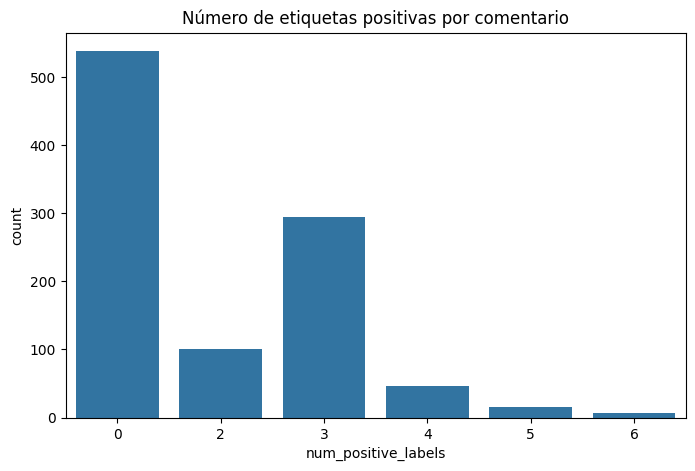

In [27]:
df['num_positive_labels'] = corr_df.sum(axis=1)

plt.figure(figsize=(8,5))

sns.countplot(x='num_positive_labels', data=df)

plt.title('Número de etiquetas positivas por comentario')
plt.show()

In [28]:
df.head(5)

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism,char_length,word_length,num_positive_labels
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False,1558,287,0
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False,138,25,2
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\r\nDont you reckon them 'black lives matter' ...,True,True,False,False,True,False,False,False,False,False,False,False,421,77,3
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False,582,107,0
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False,243,47,0


---

#### Interpretación

Esto permite entender:

- si toxicidad suele aparecer aislada
- o si varias etiquetas aparecen juntas

Muy útil para decidir:

- binary classification
- multi-label classification

---

# Sección 14

## Conclusiones accionables para el pipeline NLP

#### 1. Dataset suficientemente balanceado

IsToxic:

- 462 positivos
- 538 negativos

No hace falta oversampling agresivo.

---

#### 2. Hay etiquetas no modelables

Eliminar del entrenamiento:

- IsHomophobic
- IsRadicalism
- IsSexist

Evaluar si IsNationalist merece mantenerse.

- Con solo 8 positivos probablemente también sea demasiado escasa.

---

#### 3. Pipeline de limpieza recomendado

- Lowercase
text = text.lower()
- Eliminar URLs
regex_urls

- Eliminar puntuación innecesaria

Manteniendo:

- exclamaciones
- interrogaciones

porque pueden aportar señal emocional.

---

#### 4. No eliminar stopwords automáticamente

En toxicidad:

- pronombres
- negaciones
- conectores

pueden cambiar completamente el significado.

Ejemplo:

- "you are smart"
- "you are NOT smart"

---

#### 5. Mantener profanity/slurs

Nunca eliminar palabras ofensivas.

Son features extremadamente importantes.

---

#### 6. Targets secundarios recomendados

Etiquetas viables:

- IsAbusive
- IsObscene
- IsProvocative
- IsHatespeech
- IsRacist
- IsReligiousHate

Etiquetas borderline:

- IsThreat
- IsNationalist

---

#### 7. Estrategia de modelado recomendada

Fase 1

Binary classification:

- IsToxic

Fase 2

Multi-label classification:

- Usando únicamente etiquetas con suficiente soporte.

---

# Sección 15

## Resumen ejecutivo

---

#### Hallazgos principales

- Dataset limpio.
- Sin nulos.
- Etiquetas binarias consistentes.
- IsToxic razonablemente balanceado.
- Varias etiquetas extremadamente desbalanceadas.
- Evidencia clara de multi-label toxicity.
- Correlaciones fuertes entre toxicidad, abuso y obscenidad.

#### Riesgos
- Data scarcity (escasez de datos) en varias etiquetas.
- Posible overfitting en clases minoritarias.
- Dataset relativamente pequeño para deep learning desde cero.

#### **Recomendación final**

Priorizar:

- Modelo binario IsToxic
- Pipeline NLP robusto
- Después evolucionar a multi-label
- Excluir labels sin soporte estadístico

---